# Dataset Loading

Pull data from huggingface and download

In [1]:
import tarfile
import json
import pandas as pd

In [1]:
from huggingface_hub import snapshot_download

snapshot_download(
    repo_id="yann111/GlobalGeoTree",
    repo_type="dataset",
    local_dir="./GlobalGeoTree-6M",
    allow_patterns="GlobalGeoTree-6M/*"  # Only files in this folder
)

print("Download complete!")


c:\Users\yy21473\.GitHubFiles\dst-group-work\GlobalGeoTree\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 118 files: 100%|██████████| 118/118 [01:52<00:00,  1.05it/s]

Download complete!


# Parse dataset to dataframe

## For single tar

In [106]:

tar_path = "GlobalGeoTree-6M\GlobalGeoTree-6M\GGT_3500001_3600000-000001.tar"

small_sample = []

with tarfile.open(tar_path, "r") as tar:
    for member in tar:
        if member.isfile() and member.name.endswith(".json"):
            f = tar.extractfile(member)
            if f:
                obj = json.loads(f.read().decode("utf-8"))
                small_sample.append(obj)

                if len(small_sample) >= 1000:
                    break

# Merge every two consecutive JSON objects
merged_records = []
for i in range(0, len(small_sample), 2):
    if i+1 < len(small_sample):
        merged = {**small_sample[i], **small_sample[i+1]}
        merged_records.append(merged)
    else:
        merged_records.append(small_sample[i])  # If odd, keep last as is

df = pd.DataFrame(merged_records)


<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\yy21473\AppData\Local\Temp\ipykernel_20932\2181409932.py:1: SyntaxWarning: invalid escape sequence '\G'
  tar_path = "GlobalGeoTree-6M\GlobalGeoTree-6M\GGT_3500001_3600000-000001.tar"


## For all tars

In [2]:
from pathlib import Path
from tqdm import tqdm

def process_tar(path):
    small_sample = []
    with tarfile.open(path, "r") as tar:
        for member in tar:
            if member.isfile() and member.name.endswith(".json"):
                f = tar.extractfile(member)
                if f:
                    obj = json.loads(f.read().decode("utf-8"))
                    small_sample.append(obj)

        # Merge every two consecutive JSON objects
        merged_records = []
        for i in range(0, len(small_sample), 2):
            if i+1 < len(small_sample):
                merged = {**small_sample[i], **small_sample[i+1]}
                merged_records.append(merged)
            else:
                merged_records.append(small_sample[i])  # If odd, keep last as is

        df = pd.DataFrame(merged_records)
        return df

folder = Path("GlobalGeoTree-6M/GlobalGeoTree-6M/")

dfAll = pd.DataFrame()

tar_files = list(folder.glob("*.tar"))  # so tqdm knows the total
dfAll = pd.DataFrame()

for tar_file in tqdm(tar_files, desc="Processing tar files"):
    dfTemp = process_tar(tar_file)
    dfAll = pd.concat([dfAll, dfTemp], ignore_index=True)

Processing tar files: 100%|██████████| 118/118 [18:07<00:00,  9.21s/it]


# Save to Parquet

In [3]:
dfAll.to_parquet("GlobalGeoTree-6M/GlobalGeoTree-6M.parquet", index=False)

# Image Files

## Parse Images

In [107]:
import torch
import io


def process_tarImg(path):
    data = {'ID':[], 'imgData':[]}
    with tarfile.open(path, "r") as tar:
        for member in tar:
            if member.isfile() and member.name.endswith(".pth"):
                # Extract file as bytes
                extracted = tar.extractfile(member)
                
                # Read the file into a BytesIO buffer (makes it seekable)
                buffer = io.BytesIO(extracted.read())
                
                # Load the PyTorch object
                #data = torch.load(buffer, map_location="cpu")

                data['ID'].append(member.name.split('.')[0])
                data['imgData'].append(torch.load(buffer, map_location="cpu"))
                
                #print(member.name, type(data))
    df = pd.DataFrame(data)
    return df
        
df1Tar = process_tarImg(tar_path)
df1Tar.head()


,ID,imgData
0,3578091,"[[[tensor([415., 386., 452., 452., 416.], dtyp..."
1,3578092,"[[[tensor([208., 213., 181., 234., 213.], dtyp..."
2,3578093,"[[[tensor([255., 281., 281., 236., 204.], dtyp..."
3,3578094,"[[[tensor([176., 176., 198., 181., 163.], dtyp..."
4,3578095,"[[[tensor([332.0000, 341.0000, 416.5000, 485.5..."


## Explore Images for One Location

In [108]:
import random

indexToPlot = random.randint(0, df1Tar.shape[0])
tensorTest = df1Tar.loc[indexToPlot, 'imgData']
print(tensorTest.shape)


torch.Size([12, 10, 5, 5])


Sentintel-2 Data
- See [documentation](https://gisgeography.com/sentinel-2-bands-combinations/)

Dimensions
- 12 is for 12 months, monthly medians from Jan - Dec 2020
- 10 is 10 different bands
    - First 3 are RGB: B02, B03 and B04
    - Next two are NIR: B08, B08A
    - Next 3 are vegitation red edge: B05, B06, B07
    - Final 3 are SWIR: B11 and B12
- 5, 5 is pixels, centered on the geolocation of the tree

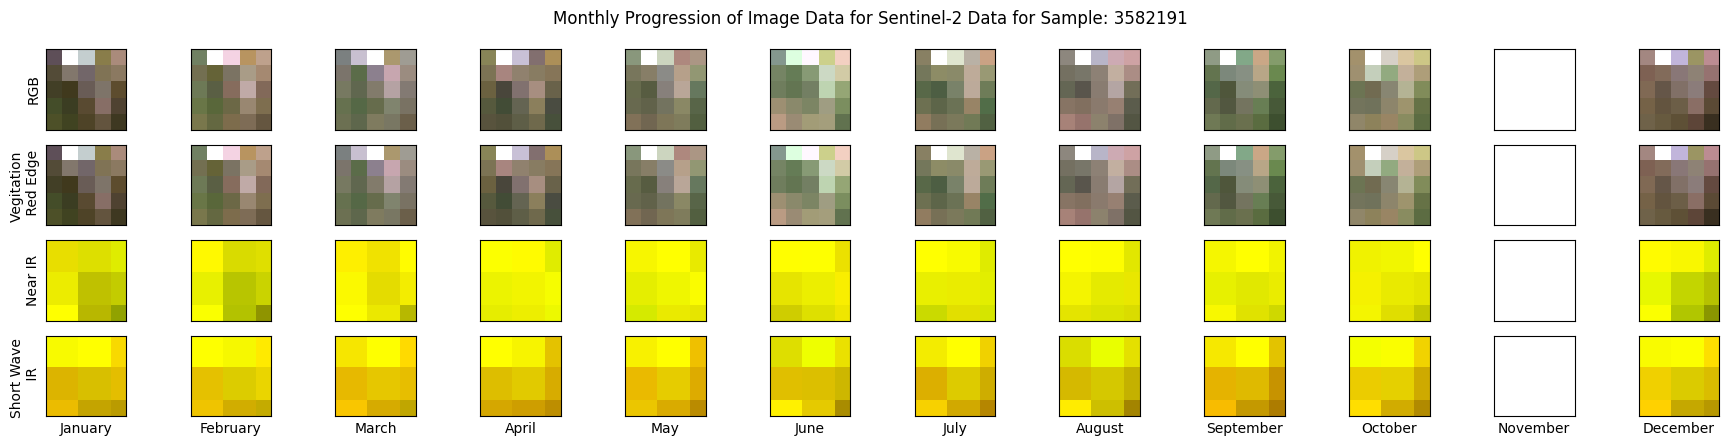

In [118]:
from matplotlib import pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

indexToPlot = random.randint(0, df1Tar.shape[0])
sampleToPlot = 234244

sampleIndex = df1Tar[df1Tar['ID'] == sampleToPlot].index.tolist()



tensorTest = df1Tar.loc[indexToPlot, 'imgData']



figImg, axImg = plt.subplots(nrows = 4, ncols = 12, figsize = (12*1.5,3*1.5))

channels = ['RGB', 'Vegitation \n Red Edge', 'Near IR',  'Short Wave \n IR']
months = ["January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"]

def normaliseRGB(imageArr):
    for c in range(3):
        maxVal = imageArr[:, :, c].max()
        if maxVal > 0:
            imageArr[:, :, c] = imageArr[:, :, c]/maxVal
    return imageArr

for i in range(12*4):
    a = i // 12
    b = i % 12

    axImg[a, b].set_aspect(1)
    axImg[3, b].set_xlabel(months[b])
    axImg[a, 0].set_ylabel(channels[a])

    axImg[a, b].xaxis.set_major_locator(ticker.NullLocator())
    axImg[a, b].yaxis.set_major_locator(ticker.NullLocator())

for b in range(12):
    # RGB
    rgb = tensorTest[b, [2, 1, 0], :, :] 
    rgb_np = normaliseRGB(rgb.permute(1, 2, 0).numpy())

    # Vegitation Red Edge
    vre = tensorTest[b, [3, 4, 5], :, :] 
    vre_np = normaliseRGB(rgb.permute(1, 2, 0).numpy())

    # NIR - only two channels so use zeros for the third
    nir = tensorTest[b, 6]
    nirA = tensorTest[b, 7]
    nirInRGB = torch.stack([nir, nirA, torch.zeros_like(nirA)], dim =0)
    nirInRGB_np = normaliseRGB(nirInRGB.permute(1, 2, 0).numpy())

    # SWIR - only two channels so use zeros for the third
    swir1 = tensorTest[b, 8]
    swir2 = tensorTest[b, 9]
    swirInRGB = torch.stack([swir1, swir2, torch.zeros_like(swir1)], dim =0)
    swirInRGB_np = normaliseRGB(swirInRGB.permute(1, 2, 0).numpy())

    axImg[0, b].imshow(rgb_np)
    axImg[1, b].imshow(vre_np)
    axImg[2, b].imshow(nirInRGB_np)
    axImg[3, b].imshow(swirInRGB_np)
    
figImg.suptitle('Monthly Progression of Image Data for Sentinel-2 Data for Sample: '+ str( df1Tar.loc[indexToPlot, 'ID']))
figImg.tight_layout()


## Notes
- Data is missing for some months, inconsitently
- NIR and SWIR only have 2 channels so not a true RGB image
- 